In [4]:
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn import neural_network
import matplotlib.pyplot as plt
from sklearn import neural_network
from sklearn import linear_model

In [5]:
# Load the data
def loadIrisData():
    from sklearn.datasets import load_iris

    data = load_iris()
    inputs = data['data']
    outputs = data['target']
    outputNames = data['target_names']
    featureNames = list(data['feature_names'])
    feature1 = [feat[featureNames.index('sepal length (cm)')] for feat in inputs]
    feature2 = [feat[featureNames.index('petal length (cm)')] for feat in inputs]
    inputs = [[feat[featureNames.index('sepal length (cm)')], feat[featureNames.index('petal length (cm)')]] for feat in inputs]
    return inputs, outputs, outputNames

inData, outData, featNames = loadIrisData()
print("feature names: ", featNames)
print("some input examples: ", inData[0], inData[50], inData[-5])
print("corresponding labels: ", outData[0], outData[50], outData[-5])

feature names:  ['setosa' 'versicolor' 'virginica']
some input examples:  [np.float64(5.1), np.float64(1.4)] [np.float64(7.0), np.float64(4.7)] [np.float64(6.7), np.float64(5.2)]
corresponding labels:  0 1 2


In [6]:
inputs, outputs, outputNames = loadIrisData()

In [7]:
# split data and normalize

def splitData(inputs, outputs):
    np.random.seed(5)
    indexes = [i for i in range(len(inputs))]
    trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace = False)
    testSample = [i for i in indexes  if not i in trainSample]

    trainInputs = [inputs[i] for i in trainSample]
    trainOutputs = [outputs[i] for i in trainSample]
    testInputs = [inputs[i] for i in testSample]
    testOutputs = [outputs[i] for i in testSample]

    return trainInputs, trainOutputs, testInputs, testOutputs

def normalisation(trainData, testData):
    scaler = StandardScaler()
    if not isinstance(trainData[0], list):
        #encode each sample into a list
        trainData = [[d] for d in trainData]
        testData = [[d] for d in testData]

        scaler.fit(trainData)  #  fit only on training data
        normalisedTrainData = scaler.transform(trainData) # apply same transformation to train data
        normalisedTestData = scaler.transform(testData)  # apply same transformation to test data

        #decode from list to raw values
        normalisedTrainData = [el[0] for el in normalisedTrainData]
        normalisedTestData = [el[0] for el in normalisedTestData]
    else:
        scaler.fit(trainData)  #  fit only on training data
        normalisedTrainData = scaler.transform(trainData) # apply same transformation to train data
        normalisedTestData = scaler.transform(testData)  # apply same transformation to test data
    return normalisedTrainData, normalisedTestData

In [8]:
# visualize the data

def data2FeaturesMoreClasses(inputs, outputs):
    labels = set(outputs)
    noData = len(inputs)
    for crtLabel in labels:
        x = [inputs[i][0] for i in range(noData) if outputs[i] == crtLabel ]
        y = [inputs[i][1] for i in range(noData) if outputs[i] == crtLabel ]
        plt.scatter(x, y, label = outputNames[crtLabel])
    plt.xlabel('feat1')
    plt.ylabel('feat2')
    plt.legend()
    plt.show()

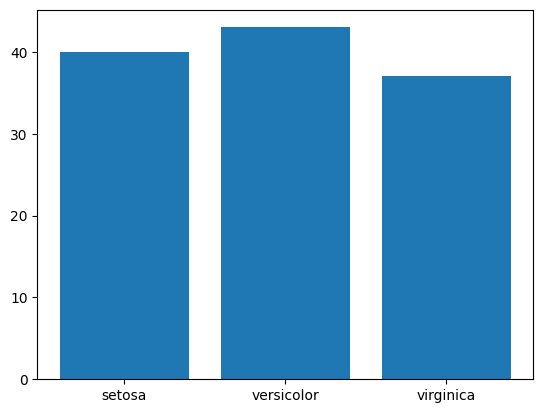

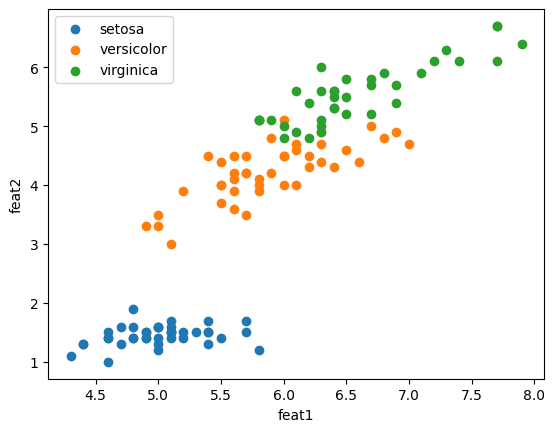

In [9]:
trainInputs, trainOutputs, testInputs, testOutputs = splitData(inputs, outputs)

# plot the training data distribution on classes
bins = range(len(outputNames) + 1)
plt.hist(trainOutputs, bins, rwidth = 0.8)
bin_w = (max(bins) - min(bins)) / (len(bins) - 1)
plt.xticks(np.arange(min(bins)+bin_w/2, max(bins), bin_w), outputNames)
plt.show()

# plot the data in order to observe the shape of the classifier required in this problem
data2FeaturesMoreClasses(trainInputs, trainOutputs)

# normalise the data
trainInputs, testInputs = normalisation(trainInputs, testInputs)

In [10]:
# liniar classifier and one-vs-all approach for multi-class
# classifier = linear_model.LogisticRegression()

# non-liniar classifier and softmax approach for multi-class
# classifier = neural_network.MLPClassifier()
classifier = neural_network.MLPClassifier(hidden_layer_sizes=(5,), activation='relu', max_iter=100, solver='sgd', verbose=10, random_state=1, learning_rate_init=.1)

# identify (by training) the classification model
classifier.fit(trainInputs, trainOutputs)

Iteration 1, loss = 0.89050498
Iteration 2, loss = 0.79020695
Iteration 3, loss = 0.70261682
Iteration 4, loss = 0.63795055
Iteration 5, loss = 0.59294737
Iteration 6, loss = 0.55980303
Iteration 7, loss = 0.53299519
Iteration 8, loss = 0.50913765
Iteration 9, loss = 0.48668042
Iteration 10, loss = 0.46438364
Iteration 11, loss = 0.44226943
Iteration 12, loss = 0.42161313
Iteration 13, loss = 0.40252943
Iteration 14, loss = 0.38534053
Iteration 15, loss = 0.37002397
Iteration 16, loss = 0.35631526
Iteration 17, loss = 0.34377371
Iteration 18, loss = 0.33211015
Iteration 19, loss = 0.32117627
Iteration 20, loss = 0.31100910
Iteration 21, loss = 0.30165144
Iteration 22, loss = 0.29309232
Iteration 23, loss = 0.28528781
Iteration 24, loss = 0.27814662
Iteration 25, loss = 0.27156702
Iteration 26, loss = 0.26545860
Iteration 27, loss = 0.25974428
Iteration 28, loss = 0.25437110
Iteration 29, loss = 0.24930393
Iteration 30, loss = 0.24408987
Iteration 31, loss = 0.23811077
Iteration 32, los

C:\Users\Mihai\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(5,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'sgd'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.1
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",100
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",1


In [11]:
predictedLabels = classifier.predict(testInputs);

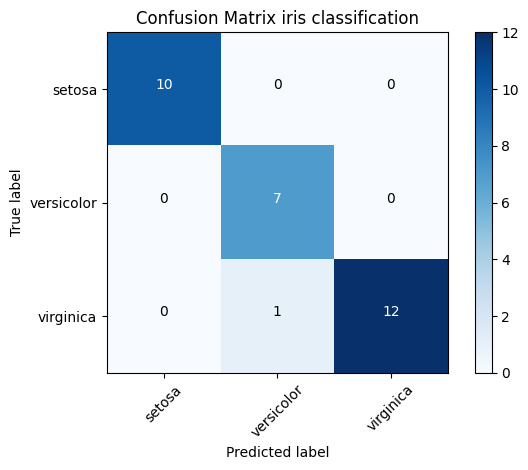

acc:  0.9666666666666667
precision:  {np.str_('setosa'): np.float64(1.0), np.str_('versicolor'): np.float64(0.875), np.str_('virginica'): np.float64(1.0)}
recall:  {np.str_('setosa'): np.float64(1.0), np.str_('versicolor'): np.float64(1.0), np.str_('virginica'): np.float64(0.9230769230769231)}


In [13]:
def plotConfusionMatrix(cm, classNames, title):
    from sklearn.metrics import confusion_matrix
    import itertools

    classes = classNames
    plt.figure()
    plt.imshow(cm, interpolation = 'nearest', cmap = 'Blues')
    plt.title('Confusion Matrix ' + title)
    plt.colorbar()
    tick_marks = np.arange(len(classNames))
    plt.xticks(tick_marks, classNames, rotation=45)
    plt.yticks(tick_marks, classNames)

    text_format = 'd'
    thresh = cm.max() / 2.
    for row, column in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(column, row, format(cm[row, column], text_format),
                horizontalalignment = 'center',
                color = 'white' if cm[row, column] > thresh else 'black')

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

    plt.show()

def evalMultiClass(realLabels, computedLabels, labelNames):
    from sklearn.metrics import confusion_matrix

    confMatrix = confusion_matrix(realLabels, computedLabels)
    acc = sum([confMatrix[i][i] for i in range(len(labelNames))]) / len(realLabels)
    precision = {}
    recall = {}
    for i in range(len(labelNames)):
        precision[labelNames[i]] = confMatrix[i][i] / sum([confMatrix[j][i] for j in range(len(labelNames))])
        recall[labelNames[i]] = confMatrix[i][i] / sum([confMatrix[i][j] for j in range(len(labelNames))])
    return acc, precision, recall, confMatrix


acc, prec, recall, cm = evalMultiClass(np.array(testOutputs), predictedLabels, outputNames)
plotConfusionMatrix(cm, outputNames, "iris classification")

print('acc: ', acc)
print('precision: ', prec)
print('recall: ', recall)

In [14]:
import numpy as np

def loadDigitData():
    from sklearn.datasets import load_digits

    data = load_digits()
    inputs = data.images
    outputs = data['target']
    outputNames = data['target_names']

    # shuffle the original data
    noData = len(inputs)
    permutation = np.random.permutation(noData)
    inputs = inputs[permutation]
    outputs = outputs[permutation]

    return inputs, outputs, outputNames

inputs, outputs, outputNames = loadDigitData()

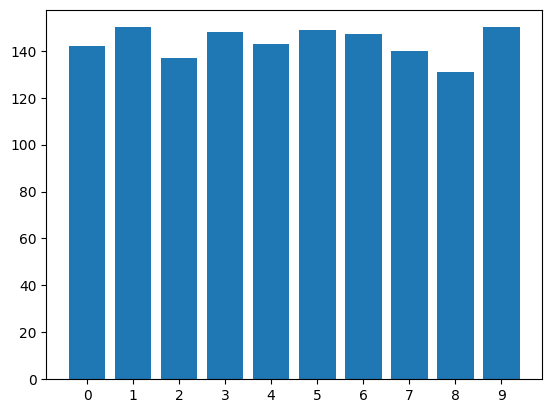

In [15]:
# split data and normalize

trainInputs, trainOutputs, testInputs, testOutputs = splitData(inputs, outputs)
# check if the data is uniform distributed over classes
bins = range(len(outputNames) + 1)
plt.hist(trainOutputs, bins, rwidth = 0.8)
bin_w = (max(bins) - min(bins)) / (len(bins) - 1)
plt.xticks(np.arange(min(bins)+bin_w/2, max(bins), bin_w), outputNames)
plt.show()

def flatten(mat):
    x = []
    for line in mat:
        for el in line:
            x.append(el)
    return x

trainInputsFlatten = [flatten(el) for el in trainInputs]
testInputsFlatten = [flatten(el) for el in testInputs]
trainInputsNormalised, testInputsNormalised = normalisation(trainInputsFlatten, testInputsFlatten)

Iteration 1, loss = 2.12872130
Iteration 2, loss = 1.20695896
Iteration 3, loss = 0.62565501
Iteration 4, loss = 0.38131855
Iteration 5, loss = 0.26257650
Iteration 6, loss = 0.20366714
Iteration 7, loss = 0.15510987
Iteration 8, loss = 0.11947880
Iteration 9, loss = 0.09488090
Iteration 10, loss = 0.07838983
Iteration 11, loss = 0.06635569
Iteration 12, loss = 0.05678090
Iteration 13, loss = 0.04994620
Iteration 14, loss = 0.04358163
Iteration 15, loss = 0.03891247
Iteration 16, loss = 0.03488271
Iteration 17, loss = 0.03150207
Iteration 18, loss = 0.02805531
Iteration 19, loss = 0.02531641
Iteration 20, loss = 0.02330273
Iteration 21, loss = 0.02138842
Iteration 22, loss = 0.02069227
Iteration 23, loss = 0.01940470
Iteration 24, loss = 0.01776792
Iteration 25, loss = 0.01634771
Iteration 26, loss = 0.01535749
Iteration 27, loss = 0.01438394
Iteration 28, loss = 0.01377485
Iteration 29, loss = 0.01303334
Iteration 30, loss = 0.01206577
Iteration 31, loss = 0.01127296
Iteration 32, los

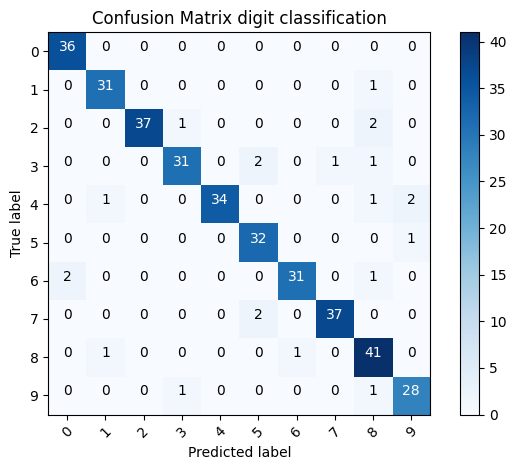

acc:  0.9388888888888889
precision:  {np.int64(0): np.float64(0.9473684210526315), np.int64(1): np.float64(0.9393939393939394), np.int64(2): np.float64(1.0), np.int64(3): np.float64(0.9393939393939394), np.int64(4): np.float64(1.0), np.int64(5): np.float64(0.8888888888888888), np.int64(6): np.float64(0.96875), np.int64(7): np.float64(0.9736842105263158), np.int64(8): np.float64(0.8541666666666666), np.int64(9): np.float64(0.9032258064516129)}
recall:  {np.int64(0): np.float64(1.0), np.int64(1): np.float64(0.96875), np.int64(2): np.float64(0.925), np.int64(3): np.float64(0.8857142857142857), np.int64(4): np.float64(0.8947368421052632), np.int64(5): np.float64(0.9696969696969697), np.int64(6): np.float64(0.9117647058823529), np.int64(7): np.float64(0.9487179487179487), np.int64(8): np.float64(0.9534883720930233), np.int64(9): np.float64(0.9333333333333333)}


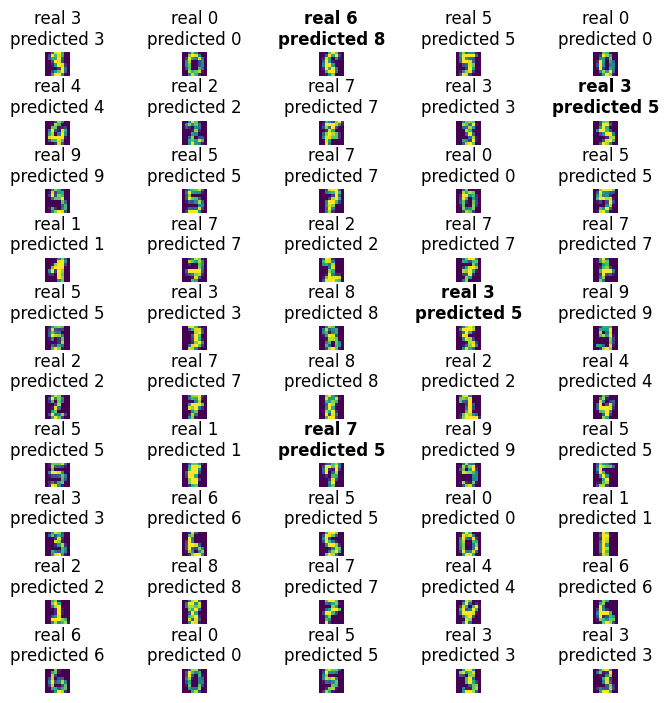

In [21]:
# try to play by MLP parameters (e.g. change the HL size from 10 to 20 and see how this modification impacts the accuracy)
classifier = neural_network.MLPClassifier(hidden_layer_sizes=(10, ), activation='relu', max_iter=100, solver='sgd', verbose=10, random_state=1, learning_rate_init=.1)

# training(classifier, trainInputsNormalised, trainOutputs)
classifier.fit(trainInputsNormalised, trainOutputs)

predictedLabels = classifier.predict(testInputsNormalised)
acc, prec, recall, cm = evalMultiClass(np.array(testOutputs), predictedLabels, outputNames)


plotConfusionMatrix(cm, outputNames, "digit classification")
print('acc: ', acc)
print('precision: ', prec)
print('recall: ', recall)

# plot first 50 test images and their real and computed labels
n = 10
m = 5
fig, axes = plt.subplots(n, m, figsize = (7, 7))
fig.tight_layout()
for i in range(0, n):
    for j in range(0, m):
        axes[i][j].imshow(testInputs[m * i + j])
        if (testOutputs[m * i + j] == predictedLabels[m * i + j]):
            font = 'normal'
        else:
            font = 'bold'
        axes[i][j].set_title('real ' + str(testOutputs[m * i + j]) + '\npredicted ' + str(predictedLabels[m * i + j]), fontweight=font)
        axes[i][j].set_axis_off()

plt.show()